In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
import matplotlib.ticker as ticker

# ODR VELOCITà LIMITE

Definisco le incertezze su tempi e spazi

In [121]:
d=[0.0015,(2/32)*0.0254,0.002, (4/32)*0.0254, (5/32)*0.0254, (8/32)*0.0254, (9/32)*0.0254]

sx1=[]
for a in range(0,len(d)):
    sx1.append((d[a]/(np.sqrt(3))))
print(sx1)

[np.float64(0.0008660254037844387), np.float64(0.000916543552338531), np.float64(0.0011547005383792516), np.float64(0.001833087104677062), np.float64(0.0022913588808463276), np.float64(0.003666174209354124), np.float64(0.0041244459855233895)]


In [122]:
N=[3,3,2,3,3,4,3]
sx=[]

for i in range (0, len(sx1)):
    sx.append(np.sqrt(2)*sx1[i])

print(sx)


[np.float64(0.0012247448713915891), np.float64(0.0012961883222227652), np.float64(0.0016329931618554523), np.float64(0.0025923766444455303), np.float64(0.0032404708055569133), np.float64(0.005184753288891061), np.float64(0.005832847450002444)]


Fit tramite ODR (numerico)

In [123]:
n_file=7
vlims=[]
svlims=[]


plt.figure(figsize=(10,10))

for j in range(1,n_file+1):
    data = np.loadtxt("R_N"+str(j)+".txt")
    
    if (j==7): 
        dx = 0.50
        row = [2.9386,	3.0776,	2.8839]
        t=(np.mean(row))
        st=(np.std(row)/np.sqrt(N[j-1]))
        vlims.append(dx/t)
        svlims.append(np.sqrt(((dx/((t)**2))*st)**2+(((1/t)*sx[j-1])**2)))

        print("Velocità limite 7: " + str(vlims[6]) + "+-" + str(svlims[6]))

    elif (j==6): 
        s = data[:,0]*10**(-2)
        t=(np.mean(data[:, 1:], axis=1))
        st=(np.std(data[:, 1:], axis=1)/np.sqrt(N[j-1]))
        dx=s[1]-s[0]
        dt=t[1]-t[0]
        sdx = np.sqrt(2)*sx[j-1]
        sdt = np.sqrt(st[1]**2+st[0]**2)
        vlims.append(dx/dt)
        svlims.append(np.sqrt((sdx/dt)**2+((dx/dt**2)*sdt)**2))#+2*(-dx/dt**2)*(1/dt)*sdt*sdx*r[0,1]))

        print("Velocità limite 6: " + str(vlims[5])+ "+-" + str(svlims[5]))
    
    else: 
        s = data[:,0]*10**(-2)
        t=(np.mean(data[:, 1:], axis=1))
        st=(np.std(data[:, 1:], axis=1)/np.sqrt(N[j-1]))
        print("Incertezze tempi"+str(st))
        print(t)

        def linear_model_odr(beta, x):
            return beta[0] * x + beta[1]

        odr_model = Model(linear_model_odr)
        odr_data  = RealData(s, t, sx=sx[j-1], sy=st)

        odr_instance = ODR(
        odr_data,
        odr_model,
        beta0=[0.0, 0.0]   # valori iniziali
        )

        odr_result = odr_instance.run()

        vlim = 1/odr_result.beta[0]
        svlim = odr_result.sd_beta[0]/odr_result.beta[0]**2

        svlims.append(svlim)
        vlims.append(vlim)

        print("=== Risultati ODR " +str(j) +"===")
        print(f"  b = {odr_result.beta[0]:.10f} ± {odr_result.sd_beta[0]:.10f} ")
        print(f"  a = {odr_result.beta[1]:.10f} ± {odr_result.sd_beta[1]:.10f} ")
        print(f"  Vl = {vlim:.10f} ± {svlim:.10f} ")

print(svlims)
print(vlims)


Incertezze tempi[0.01044502 0.05261124 0.06308938 0.14969598 0.08249224 0.09426531
 0.08312839 0.12493198 0.14910163 0.1544971 ]
[ 5.91116667 11.86376667 17.91753333 24.6382     30.38236667 36.7997
 43.1569     49.84306667 56.4772     63.28206667]
=== Risultati ODR 1===
  b = 126.8635870639 ± 0.8991304442 
  a = -0.8866701496 ± 0.2572729382 
  Vl = 0.0078824825 ± 0.0000558661 
Incertezze tempi[0.06209119 0.0614376  0.03495391 0.05716526 0.06253769 0.03416704
 0.04968476 0.04207338 0.03432817 0.05582057]
[ 5.15976667 10.39893333 15.7937     21.19483333 26.7551     32.3164
 38.0406     43.78583333 49.71923333 55.7134    ]
=== Risultati ODR 2===
  b = 112.3415852614 ± 0.8056511675 
  a = -1.0107684385 ± 0.2516094509 
  Vl = 0.0089014233 ± 0.0000638360 
Incertezze tempi[0.00774282 0.00311127 0.057311   0.05140666 0.04557303 0.04546697
 0.08481746 0.04253247 0.05600286 0.0675287 ]
[ 3.24655  6.5604   9.88245 13.3499  16.88535 20.3285  23.96875 27.67025
 31.3636  35.1902 ]
=== Risultati ODR 

<Figure size 1000x1000 with 0 Axes>

## CALCOLO VISCOSITà E CORREZIONI 

VISCOSITà SENZA CORREZIONI:
[np.float64(1.0279296135265494), np.float64(1.0195578872114883), np.float64(1.0206498628901643), np.float64(1.0275614594971825), np.float64(1.034824946542741), np.float64(1.0836456868137), np.float64(1.0904355343269134)]
[np.float64(0.02186719635098486), np.float64(0.021717808626228918), np.float64(0.02193952539398505), np.float64(0.022475303022099023), np.float64(0.022607374850987842), np.float64(0.053239034099429504), np.float64(0.03065237529218683)]


VELOCITà FONDO PARETE:
[np.float64(0.008226766773756078), np.float64(0.009312969057775003), np.float64(0.014936040681664315), np.float64(0.03860627909485727), np.float64(0.06118120768033652), np.float64(0.1590357039166853), np.float64(0.2040224219114914)]
[np.float64(6.521420435637769e-05), np.float64(7.504653526443451e-05), np.float64(0.00013198055959691416), np.float64(0.0004027739106619213), np.float64(0.0006581541304024811), np.float64(0.00764004896799528), np.float64(0.004738627520154712)]


VISCOSITà F

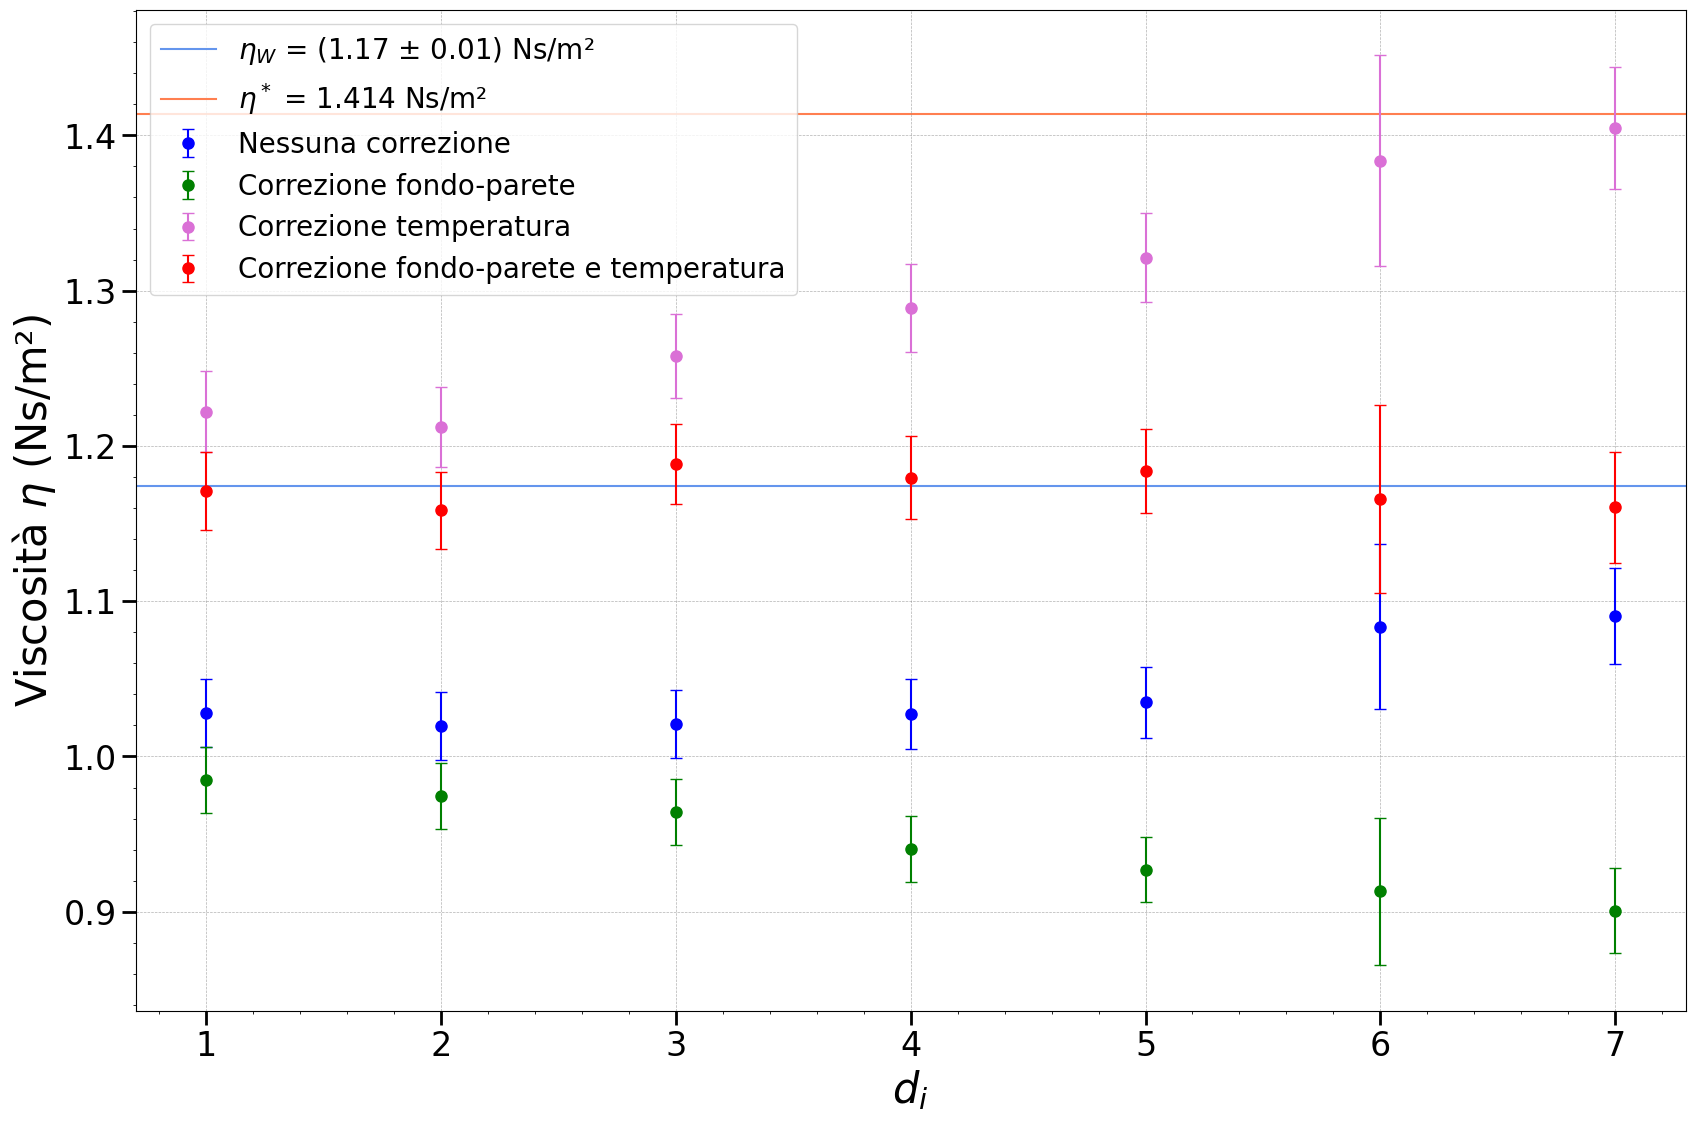

In [124]:
#DATI NEWTONIANO
eta=[]
s_eta=[]
p= 7.870 * 10**3
p0= 1.26 * 10**3 
sp=0.001 * 10**3
sp0=0.01 * 10**3
g=9.80652
sd=[]

for i in range(len(d)):
    sd.append(d[i]*0.01)

#CALCOLO VISCOSITà SENZA CORREZIONI
for i in range(0, len(vlims)):
    D = d[i]
    n = (1/18)*(g*(p-p0)*(D**2))/vlims[i]
    eta.append(n)
    s_n=np.sqrt((g*(p-p0)/(9*vlims[i])*D*sd[i])**2+((g*(p-p0)*D**2/(18*vlims[i]**2))*svlims[i])**2+(g*D**2/(18*vlims[i])*sp)**2+(g*D**2/(18*vlims[i])*sp0)**2)
    s_eta.append(s_n)

#Inizio grafico
plt.figure(figsize=(20,13))
x=[1,2,3,4,5,6,7] #Ordinali per i diametri
plt.errorbar(x, eta, fmt='o', yerr=s_eta, capsize=4, ms=8, color='blue', ecolor='blue', label='Nessuna correzione', zorder=2) #Visco senza correzioni
print("VISCOSITà SENZA CORREZIONI:")
print(eta)
print(s_eta)
print("\n")

#///////////////////////
#CORREZIONE SISTEMATICHE
#1) FONDO PARETE

vlimsFP=[]
svlimsFP=[]
R=4.5*10**(-2)
H=70*10**(-2) #Dati viscosimetro supposti privi di errore

#Calcolo velocità fondo-parete + incertezze propag.
for i in range(0, len(vlims)):
    D = d[i]
    r = D/2
    vlimsFP.append(vlims[i]*(1+2.4*r/R)*(1+3.3*r/H))
    svlimsFP.append(svlims[i]*(1+2.4*r/R)*(1+3.3*r/H)+vlims[i]*(2.4/R)*(1+3.3*r/H)*sd[i]+vlims[i]*(1+2.4*r/R)*3.3/H*sd[i])

print("VELOCITà FONDO PARETE:")
print(vlimsFP)
print(svlimsFP)
print("\n")


#Viscosità fondo-parete + incertezze propag.
etaFP=[]
s_etaFP=[]
for i in range(0, len(vlimsFP)):
    D = d[i]
    p= 7.870 * 10**3
    p0= 1.26 * 10**3 
    g= 9.80652
    n = (1/18)*(g*(p-p0)*(D**2))/vlimsFP[i]
    etaFP.append(n)
    s_etaFP.append(np.sqrt((g*(p-p0)/(9*vlimsFP[i])*D*sd[i])**2+((g*(p-p0)*D**2/(18*vlimsFP[i]**2))*svlimsFP[i])**2+(g*D**2/(18*vlimsFP[i])*sp)**2+(g*D**2/(18*vlimsFP[i])*sp0)**2))

plt.errorbar(x, etaFP, yerr=s_etaFP, fmt='o', capsize=4, ms=8, color='green', ecolor='green', label='Correzione fondo-parete', zorder=2)
print("VISCOSITà FONDO PARETE:")
print(etaFP)
print(s_etaFP)
print("\n")

#2) TEMPERATURA
#T0=20°C

T=[21.9,21.9,22.3,22.5,22.7,22.7,22.8]
etastar1=[1.1893,1.1893, 1.1474, 1.1271, 1.1073, 1.1073, 1.0975] #eta da sito
etastar0=1.4138 #Valore di riferimento a 20°C 
etaTFP=[]
etaT=[]
s_etaT=[]
s_etaTFP=[]
for i in range(0, len(eta)):
    etaT.append(etastar0/etastar1[i]*eta[i])
    etaTFP.append(etastar0/etastar1[i]*etaFP[i])
    s_etaT.append(etastar0/etastar1[i]*s_eta[i])
    s_etaTFP.append(etastar0/etastar1[i]*s_etaFP[i])

print("VISCOSITà TEMPERATURA:")
print(etaT)
print(s_etaT)
print("\n")

print("VISCOSITà ENTRAMBE CORREZIONI:")
print(etaTFP)
print(s_etaTFP)
print("\n")

#Grafico
plt.errorbar(x, etaT, fmt='o', yerr=s_etaT, capsize=4, ms=8, color='orchid', ecolor='orchid', label='Correzione temperatura', zorder=2)
plt.errorbar(x, etaTFP, fmt='o', yerr=s_etaTFP, capsize=4, ms=8, color='red', ecolor='red', label='Correzione fondo-parete e temperatura', zorder=2)

#/////////////////////////
#FIT MEDIA PESATA
wmean = 0
wsum=0
incsum=0
for i in range (0, len(etaT)):
    w = 1/s_etaTFP[i]**2
    wsum+=w*etaTFP[i]
    incsum+=w

wmean = wsum/incsum

incwmean = np.sqrt(1/incsum)
print("Viscosità media pesata: ")
print(incwmean)
print(wmean)

expected=1.4138

#Grafico
plt.axhline(y=wmean, color='cornflowerblue', linestyle='-', label=f'$\eta_W$ = ({wmean:.2f} $\pm$ {incwmean:.2f}) Ns/m²', zorder=1)
plt.axhline(y=expected, color='coral', linestyle='-', label=f'$\eta^*$ = {expected:.3f} Ns/m²', zorder=1)
plt.xlabel(f'$d_i$', fontsize=30)
plt.ylabel(f'Viscosità $\eta$ (Ns/m²)', fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.ylim(1.1,1.26)
plt.grid(linestyle='--', linewidth=0.5, alpha=0.6, color='gray')
plt.minorticks_on()
plt.legend(fontsize=20)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=24, length=10, width=2)

In [125]:

#CHI SQUARES e errore a posteriori
chi = 0
spostsum=0
spost=0
for i in range (0, len(etaTFP)):
    chi += (etaTFP[i]-wmean)**2/(s_etaTFP[i]**2)
    spostsum += (etaTFP[i]-wmean)**2/6

print(np.sqrt(spostsum))
print(chi)




0.011791312254530726
1.041994924281911


2.8867513459481293e-05
[np.float64(0.0012247448713915891), np.float64(0.0012961883222227652), np.float64(0.0016329931618554523), np.float64(0.0025923766444455303), np.float64(0.0032404708055569133), np.float64(0.005184753288891061), np.float64(0.005832847450002444)]

VELOCITà LIMITE 1
[np.float64(0.0002075276019742905), np.float64(0.0002028428583980199), np.float64(0.00019987676769385684), np.float64(0.00019339400473693296), np.float64(0.00019908400556978696), np.float64(0.00019167186644691796), np.float64(0.0001937979481126012), np.float64(0.0001794550594378874), np.float64(0.00018175334126621726), np.float64(0.00017979754099084778)]
[np.float64(0.00847227870408025), np.float64(0.008281024859636629), np.float64(0.008159934720522235), np.float64(0.007895277045271524), np.float64(0.008127570344121324), np.float64(0.007824971047607121), np.float64(0.007911767963669172), np.float64(0.007326222013831902), np.float64(0.007420048972323221), np.float64(0.007340203764056483)]
[np.float64(0.000

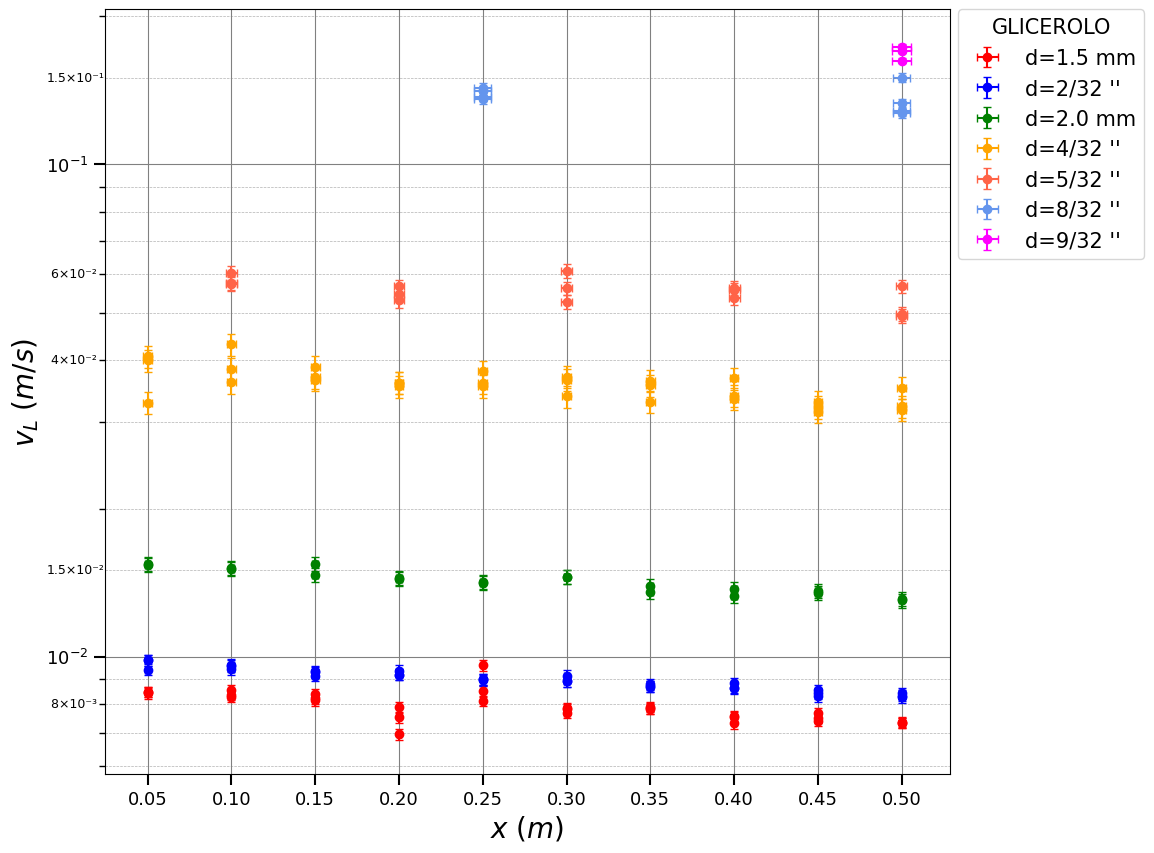

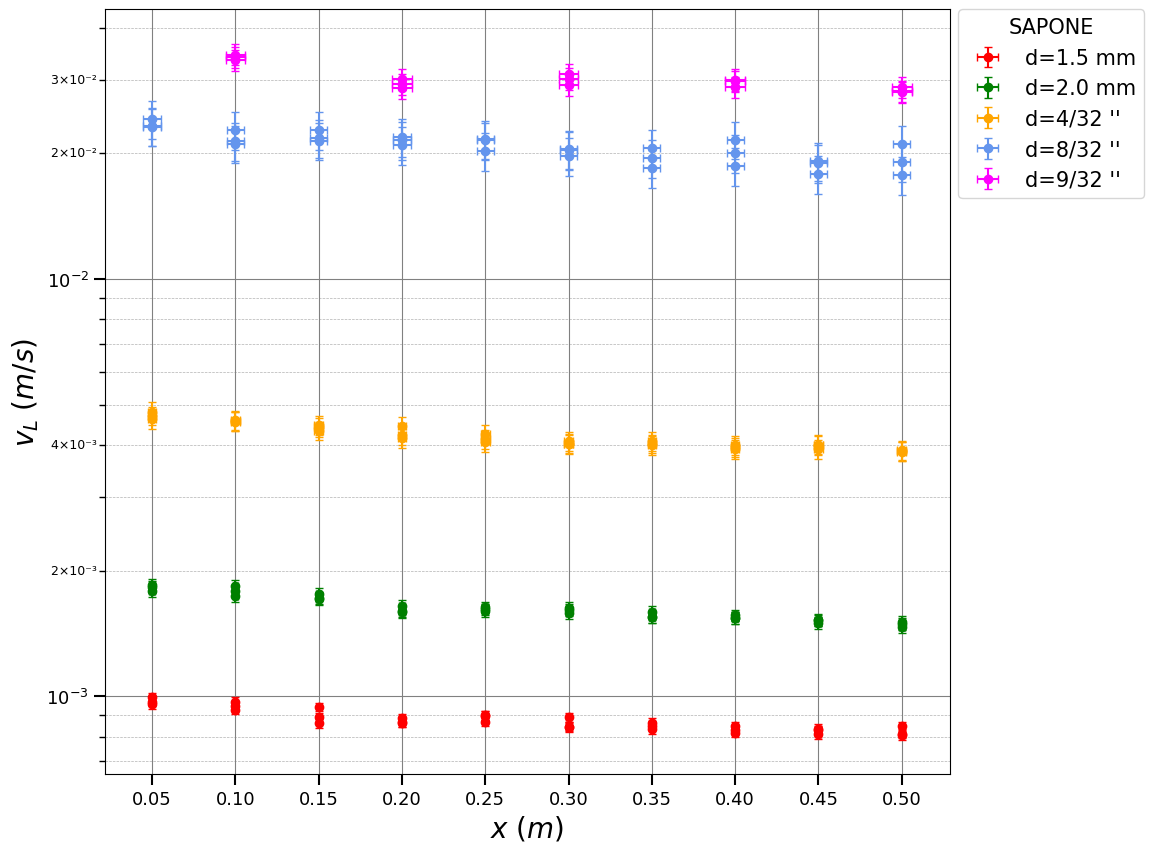

In [126]:
# GRAFICO IN ITINERE
t_res=0.0001
st=(t_res/(2*np.sqrt(3)))
print(st)


d=[0.0015,(2/32)*0.0254,0.002, (4/32)*0.0254, (5/32)*0.0254, (8/32)*0.0254, (9/32)*0.0254]
etic=["1.5 mm", "2/32 ''", "2.0 mm", "4/32 ''", "5/32 ''", "8/32 ''", "9/32 ''"]

sx=[]

for a in range(0,len(d)):
    sx.append(np.sqrt(2)*(d[a]/(np.sqrt(3))))

print(sx)

plt.figure(figsize=(13, 9))

cmap = ["red", "blue", "green", "orange", "tomato", "cornflowerblue", "magenta"]

n_file=7

for j in range(1,n_file+1):
    print('\n'"VELOCITà LIMITE " + str(j))
    color = cmap[j-1]
    data = np.loadtxt("R_N"+str(j)+".txt", ndmin=2)
    data = np.insert(data, 0, 0, axis=0)
    
    x = data[:,0]*10**(-2)


    n_cols = data.shape[1] - 1 
    t = [data[:, k] for k in range(1, n_cols + 1)]
    
    for a in range(n_cols):
        vl=[]
        svl=[]
        x_plot=[]
        tempi = t[a]
        

        deltax=0
        deltat=0
        for i in range(1,len(x)):
            deltax = x[i]-x[i-1]
            deltat = tempi[i]-tempi[i-1]
            
            if deltat <= 0:
                continue
                
            vl.append(deltax/deltat)
            svl.append(np.sqrt(((deltax/((deltat)**2))*st)**2+(((1/deltat)*sx[j-1])**2)))
            x_plot.append(x[i])

        print(svl)
        print(vl)



        plt.errorbar(x_plot,vl,fmt='o',xerr=sx[j-1], yerr=svl,capsize=3 ,ms=6, color=color, ecolor=color, label = r"d=" + str(etic[j-1]) if a == 0 else "_nolegend_")

        

plt.xlabel(r"$x$ $(m)$", fontsize=20)
plt.ylabel(r"$v_L$ $(m/s)$", fontsize=20)

legend=plt.legend(fontsize=15, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
legend.set_title("GLICEROLO", prop={'size': 15})
#plt.title("GLICEROLO", fontsize=30)
plt.tight_layout()
plt.subplots_adjust(left=0.1, right=0.75, top=0.95, bottom=0.1)

plt.grid(True, which='major', linestyle='-', linewidth=0.8, color='gray')
plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.6, color='gray')
plt.yscale('log')

ax = plt.gca()

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='auto', numticks=15))

ax.tick_params(axis='x', which='minor', bottom=False)

ax.tick_params(axis='both', which='major', labelsize=13, length=8, width=1.5)
ax.tick_params(axis='y', which='minor', length=4, width=1.0)

ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.8, color='gray')
ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.8, color='gray')
ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.5, alpha=0.6, color='gray')

ax.axhline(y=1.5e-2, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)
ax.axhline(y=1.5e-1, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)

valori_e_label = [
    (1.5e-2, '1.5×10⁻²'),
    (1.5e-1, '1.5×10⁻¹'),
    (4e-2, '4×10⁻²  '),
    (6e-2, '6×10⁻²  '),
    (8e-3, '8×10⁻³  ')
]

for val, etichetta in valori_e_label:
    ax.text(
        ax.get_xlim()[0],  
        val,
        etichetta,
        fontsize=9,
        va='center',
        ha='right',
        transform=ax.transData
    )

d=[0.0015,0.002, (4/32)*0.0254, (8/32)*0.0254, (9/32)*0.0254]

sx=[]
etic=["1.5 mm", "2.0 mm", "4/32 ''", "8/32 ''", "9/32 ''"]

pedice=[1,3,4,6,7]

for a in range(0,len(d)):
    sx.append(np.sqrt(2)*(d[a]/(np.sqrt(3))))

print(sx)

plt.figure(figsize=(13, 9))
cmap = ["red", "green", "orange", "cornflowerblue", "magenta"]

n_file=5

for j in range(1,n_file+1):
    print('\n'"VELOCITà LIMITE " + str(j))
    color = cmap[j-1]
    data = np.loadtxt("R_NN"+str(j)+".txt", ndmin=2)
    data = np.insert(data, 0, 0, axis=0)
    
    x = data[:,0]*10**(-2)


    n_cols = data.shape[1] - 1 
    t = [data[:, k] for k in range(1, n_cols + 1)]
    
    for a in range(n_cols):
        vl=[]
        svl=[]
        x_plot=[]
        tempi = t[a]
        

        deltax=0
        deltat=0
        for i in range(len(x)):
            deltax = x[i]-x[i-1]
            deltat = tempi[i]-tempi[i-1]
            
            if deltat <= 0:
                continue
                
            vl.append(deltax/deltat)
            svl.append(np.sqrt(((deltax/((deltat)**2))*st)**2+(((1/deltat)*sx[j-1])**2)))
            x_plot.append(x[i])

        print(svl)
        print(vl)



        plt.errorbar(x_plot,vl,fmt='o',xerr=sx[j-1], yerr=svl,capsize=3 ,ms=6, color=color, ecolor=color, label = r"d=" +etic[j-1] if a == 0 else "_nolegend_")

        

plt.xlabel(r"$x$ $(m)$", fontsize=20)
plt.ylabel(r"$v_L$ $(m/s)$", fontsize=20)

legend=plt.legend(fontsize=15, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
legend.set_title("SAPONE", prop={'size': 15})
#plt.title("SAPONE NON NEWTONIANO", fontsize=30)
plt.subplots_adjust(left=0.1, right=0.75, top=0.95, bottom=0.1)

plt.grid(True, which='major', linestyle='-', linewidth=0.8, color='gray')
plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.6, color='gray')
plt.yscale('log')

ax = plt.gca()

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='auto', numticks=15))

ax.tick_params(axis='x', which='minor', bottom=False)

ax.tick_params(axis='both', which='major', labelsize=13, length=8, width=1.5)
ax.tick_params(axis='y', which='minor', length=4, width=1.0)

ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.8, color='gray')
ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.8, color='gray')
ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.5, alpha=0.6, color='gray')

valori_e_label = [
    (2e-2, '2×10⁻²  '),
    (3e-2, '3×10⁻²  '),
    (4e-3, '4×10⁻³  '),
    (2e-3, '2×10⁻³  '),
    
]

for val, etichetta in valori_e_label:
    ax.text(
        ax.get_xlim()[0],  
        val,
        etichetta,
        fontsize=9,
        va='center',
        ha='right',
        transform=ax.transData
    )